In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# ADMM MPC

直接按 canonical 3-agent 配置生成 ADMM MPC + LSTM 测试结果，并写入 `notebooks/record/mpc/admm_mpc_lstm/`。

In [2]:

from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from configs.experiment_config import ADMM_NOTEBOOK_SPEC
from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.mainline_compare import compare_rollout_metrics
from scripts.utils.admm_mpc_notebook_helpers import collect_admm_mpc_rollout
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings, bootstrap_madrl_notebook_shared_data, plot_battery_power_and_soc_comparison, plot_net_load_comparison, plot_power_balance_comparison, plot_price_prediction_comparison, plot_voltage_profile_comparison, save_rollout_record
from scripts.utils.torch_runtime import configure_torch_runtime


In [3]:

root = project_root()
cfg = compose_experiment_config(forecast_type='lstm', data_dir=root / 'data', runtime_mode='performance', seed=0)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(cfg, prediction_mode='normal', test_start_date=None, test_end_date=None, agent_profiles=None, agent_bus_ids=None, load_scale=None, pv_scale=None, future_horizon=int(forecast_controls['future_horizon']), battery_controls=None, forecast_controls=forecast_controls, train_year=None, test_year=None)
cfg.forecast.auto_train_missing = False
bootstrap_madrl_notebook_shared_data(cfg, root=root, notebook_path='notebooks/madrl/ADMM_mpc.ipynb')
runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

rollout = collect_admm_mpc_rollout(cfg, prediction_mode=str(ADMM_NOTEBOOK_SPEC['prediction_mode']), label=str(ADMM_NOTEBOOK_SPEC['display_label']), show_progress=bool(ADMM_NOTEBOOK_SPEC['show_progress']), rho_init=ADMM_NOTEBOOK_SPEC['rho_init'], rho_min=float(ADMM_NOTEBOOK_SPEC['rho_min']), rho_max=float(ADMM_NOTEBOOK_SPEC['rho_max']), rho_adaptation=str(ADMM_NOTEBOOK_SPEC['rho_adaptation']), max_iters=int(ADMM_NOTEBOOK_SPEC['max_iters']), max_iters_first_step=int(ADMM_NOTEBOOK_SPEC['max_iters_first_step']), primal_tol=float(ADMM_NOTEBOOK_SPEC['primal_tol']), dual_tol=float(ADMM_NOTEBOOK_SPEC['dual_tol']))
save_rollout_record(rollout, category='mpc', scheme_name=str(ADMM_NOTEBOOK_SPEC['scheme_name']), root=root, config_snapshot={'cfg_summary': summarize_experiment(cfg), 'prediction_mode': 'normal'})
metrics_df = compare_rollout_metrics(rollout)
display(metrics_df)
pprint({'record_dir': str(root / 'notebooks' / 'record' / 'mpc' / ADMM_NOTEBOOK_SPEC['scheme_name'])})


c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-

ADMM MPC rollout:   0%|          | 0/672 [00:00<?, ?step/s]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2685996
Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


,controller,soc_mode,purchase_cost_total,purchase_cost_total_eur,export_subsidy_total,export_subsidy_total_eur,total_cost_eur,objective_total,soc_penalty_total,voltage_penalty_total,...,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur,purchase_cost_sfh12,purchase_cost_sfh18,purchase_cost_sfh20
0,ADMM MPC + LSTM Forecast,continuous,602.158843,602.158843,0.0,0.0,602.158843,602.158843,0.0,0.0,...,0.06326,0,59.697891,11.621154,150.603943,5.767654,NaN,231.818906,172.524668,197.815268


{'record_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\notebooks\\record\\mpc\\admm_mpc_lstm'}


1. 电力电量平衡


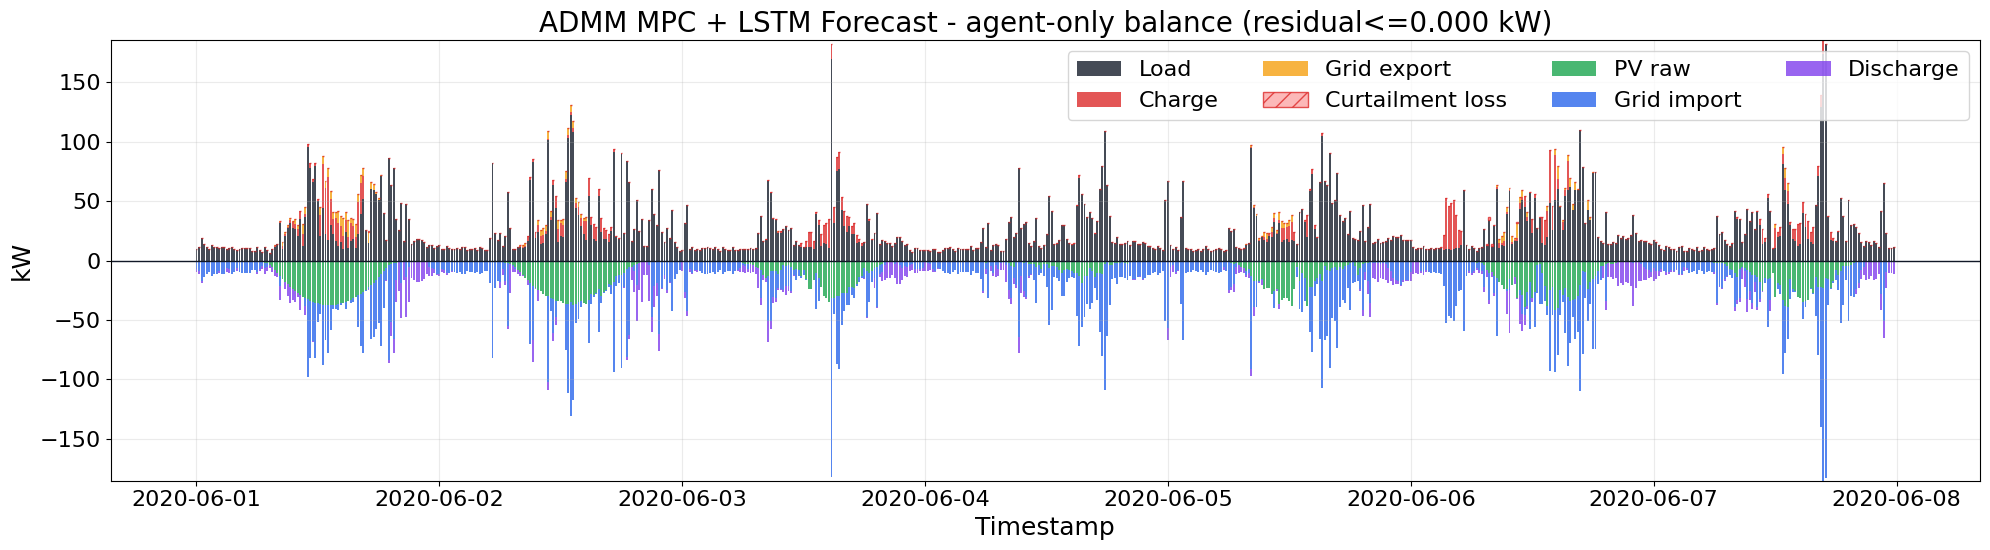

2. 电价


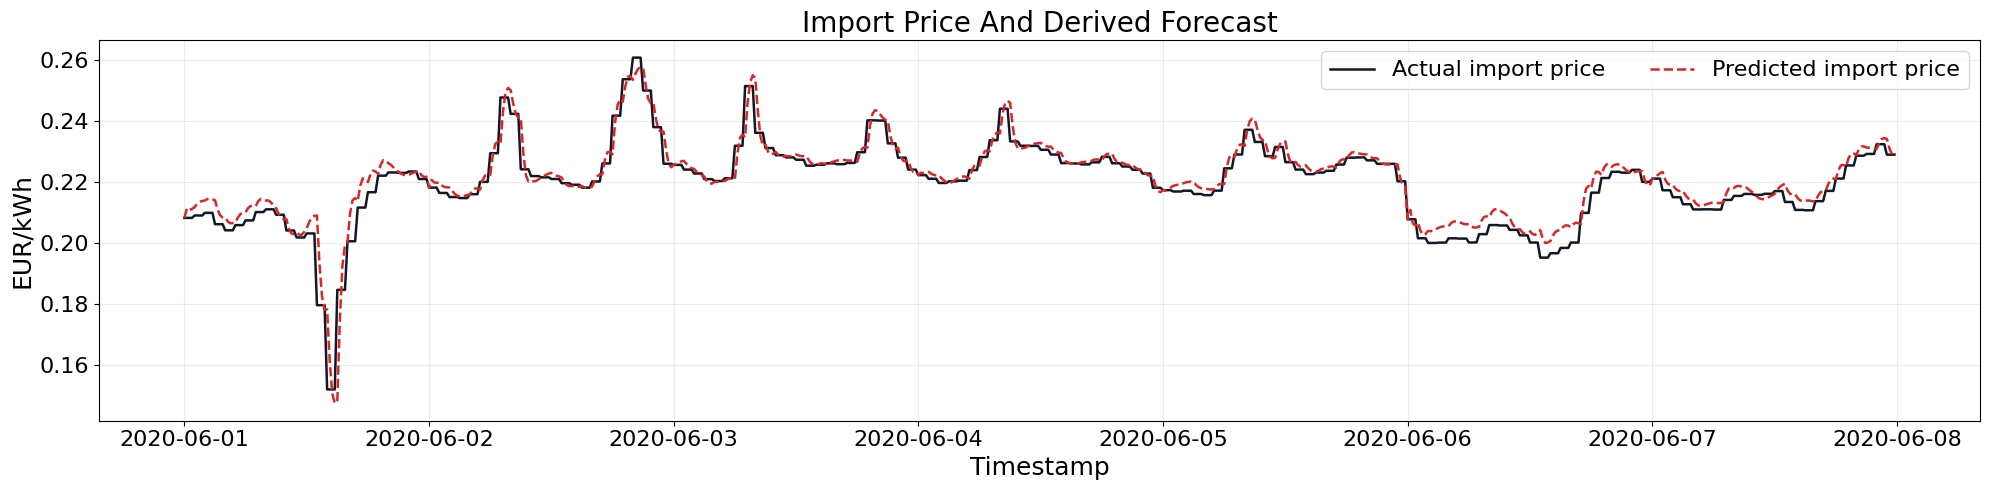

3. 总体储能充放功率与 SoC


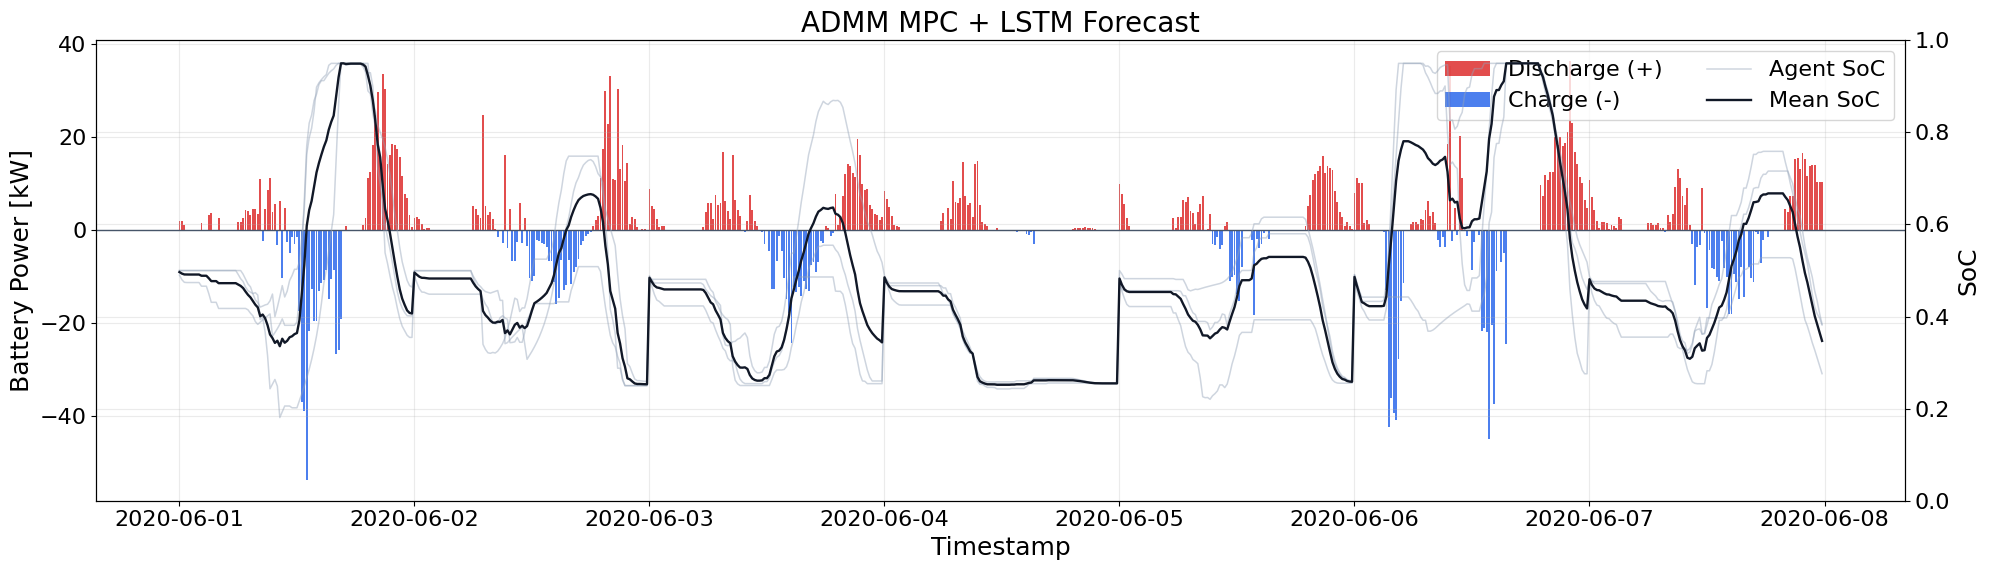

4. 电压


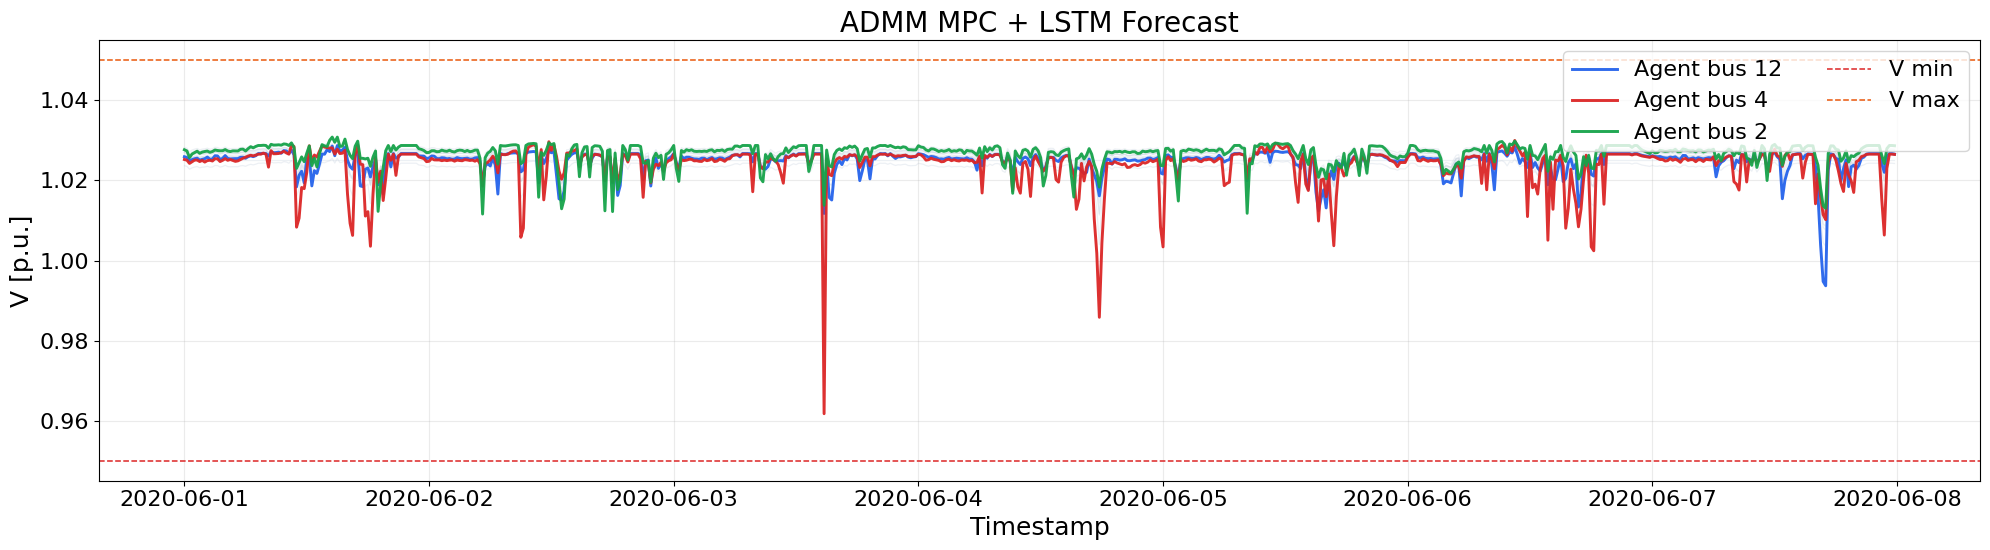

5. 净负荷


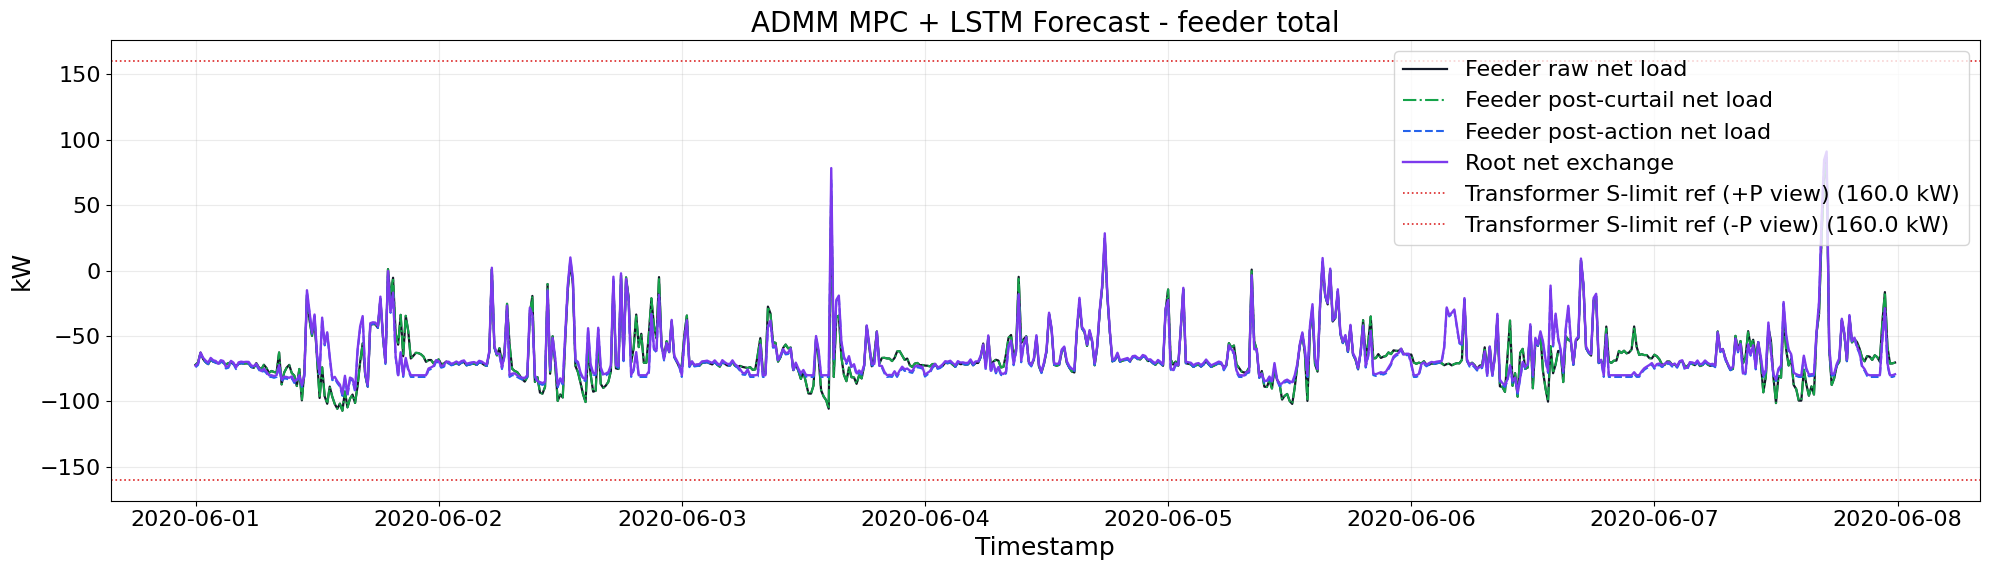

In [4]:
# 统一展示 ADMM MPC 的关键图，和 MISOCP notebook 保持同一套验收视角。
_plot_specs = [
    ('1. 电力电量平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 总体储能充放功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(rollout)
    display(figure)
    plt.close(figure)
